# Day 1 (Re-run) — EDA & Data Cleaning on Expanded Dataset
YouTube Real-Time Engagement Prediction Project

This is a RE-RUN of the original Day 1 pipeline, now using the expanded
dataset collected via the automated AWS Lambda + MongoDB pipeline
(Phase 3/4), instead of the original one-time 80k-row CSV.

Same cleaning logic as before — the MongoDB export was deliberately built
to match the original raw CSV's exact column structure, so no changes to
the actual cleaning steps are needed.

Goal for today:
1. Load and inspect the raw data
2. Check missing values and snapshot coverage per video
3. Visualize key patterns (EDA)
4. Clean the data (fill missing values properly, no shortcuts)
5. Save a clean version for Day 2 (feature engineering)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

RAW_PATH = "C:/Users/Lenovo/youtube_enagagement_project/data/raw/youtube_mongodb_export.csv"
PROCESSED_PATH = "C:/Users/Lenovo/youtube_enagagement_project/data/processed/03cleaned_data_v2_upgrade.csv"

df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
df.head()

Shape: (105718, 15)


,video_id,title,channel,published_at,category_id,duration,views,likes,comments,snapshot_time,video_age_hours,views_per_hour,like_rate,comment_rate,engagement_rate
0,L_mx5dTN_QI,@talibkhan-o4k is live। # video,@talibkhan-o4k,2026-09-05 09:00:14+00:00,23.0,PT9M11S,473,0,0,2026-09-05 10:26:22.421000+00:00,1.435672,329.462325,0.000000,0.000000,0.000000
1,95GN0a-rN0s,Hello family members support GPay/sathi.das568...,Rong_Rup_er_protidin,2026-09-05 09:42:27+00:00,22.0,PT1H1M59S,1372,21,1,2026-09-05 10:26:22.421000+00:00,0.732061,1874.159764,1.530612,0.072886,1.603499
2,OmetGLD-Oos,De Miko SUMUŠTAS... Seniausia Lietuvos Drama,Emilis Jokūbas,2026-09-05 08:00:27+00:00,23.0,PT21M25S,6246,427,47,2026-09-05 10:26:22.421000+00:00,2.432061,2568.191752,6.836375,0.752482,7.588857
3,L_mx5dTN_QI,@talibkhan-o4k is live। # video,@talibkhan-o4k,2026-09-05 09:00:14+00:00,23.0,PT9M11S,473,0,0,2026-09-05 10:36:24.214000+00:00,1.602837,295.101707,0.000000,0.000000,0.000000
4,OmetGLD-Oos,De Miko SUMUŠTAS... Seniausia Lietuvos Drama,Emilis Jokūbas,2026-09-05 08:00:27+00:00,23.0,PT21M25S,6583,445,59,2026-09-05 10:36:24.214000+00:00,2.599226,2532.676927,6.759836,0.896248,7.656084


## 1. Basic inspection

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105718 entries, 0 to 105717
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   video_id         105718 non-null  str    
 1   title            105718 non-null  str    
 2   channel          105718 non-null  str    
 3   published_at     105718 non-null  str    
 4   category_id      105718 non-null  float64
 5   duration         105718 non-null  str    
 6   views            105718 non-null  int64  
 7   likes            105718 non-null  int64  
 8   comments         105718 non-null  int64  
 9   snapshot_time    105718 non-null  str    
 10  video_age_hours  105718 non-null  float64
 11  views_per_hour   105718 non-null  float64
 12  like_rate        105718 non-null  float64
 13  comment_rate     105718 non-null  float64
 14  engagement_rate  105718 non-null  float64
dtypes: float64(6), int64(3), str(6)
memory usage: 28.3 MB


In [3]:
df.isnull().sum()

video_id           0
title              0
channel            0
published_at       0
category_id        0
duration           0
views              0
likes              0
comments           0
snapshot_time      0
video_age_hours    0
views_per_hour     0
like_rate          0
comment_rate       0
engagement_rate    0
dtype: int64

Only a couple of fully-null rows — safe to drop them outright.

In [4]:
df = df.dropna(subset=["video_id", "video_age_hours"]).copy()
print("Shape after dropping null id/age rows:", df.shape)

Shape after dropping null id/age rows: (105718, 15)


## 2. Unique videos / channels / categories
Remember: total ROWS will be far higher than unique VIDEOS (each video has
many snapshots, collected every 10 minutes). The number of unique videos
is our real sample size for modeling later.

In [5]:
print("Unique videos:", df["video_id"].nunique())
print("Unique channels:", df["channel"].nunique())
print("Unique categories:", df["category_id"].nunique())

snapshots_per_video = df.groupby("video_id").size()
print("\nSnapshots per video — summary:")
print(snapshots_per_video.describe())

Unique videos: 654
Unique channels: 592
Unique categories: 14

Snapshots per video — summary:
count    654.000000
mean     161.648318
std       44.823819
min        2.000000
25%      176.000000
50%      183.000000
75%      186.000000
max      192.000000
dtype: float64


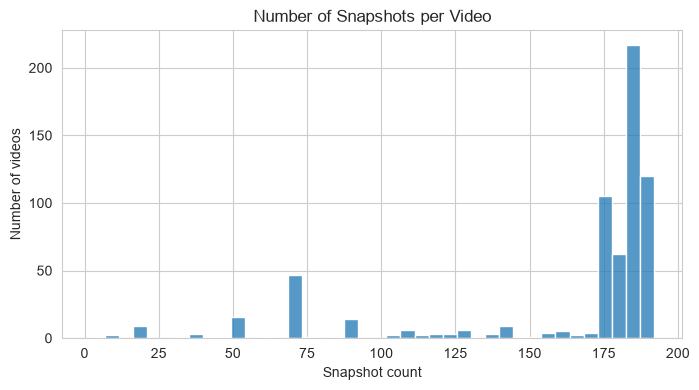

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(snapshots_per_video, bins=40)
plt.title("Number of Snapshots per Video")
plt.xlabel("Snapshot count")
plt.ylabel("Number of videos")
plt.show()

## 3. Missing-data heatmap
Visual check of where nulls occur (should be near-empty after our earlier dropna,
but useful to show in the report as evidence of the storage-gap issue).

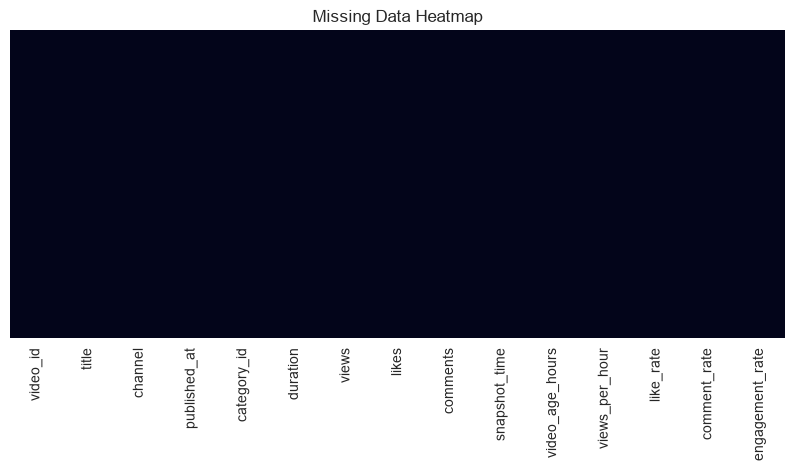

In [7]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Data Heatmap")
plt.show()

## 4. Engagement rate distribution
Expect a right-skewed distribution — most videos have low engagement,
a few have very high engagement (viral outliers).

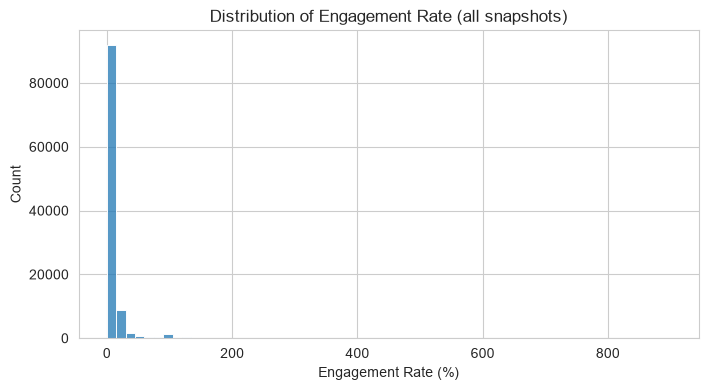

count    105718.000000
mean          9.038415
std          21.555628
min           0.000000
25%           1.115242
50%           3.681790
75%           8.633094
max         900.000000
Name: engagement_rate, dtype: float64


In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df["engagement_rate"], bins=60)
plt.title("Distribution of Engagement Rate (all snapshots)")
plt.xlabel("Engagement Rate (%)")
plt.show()

print(df["engagement_rate"].describe())

## 5. Category-wise average engagement

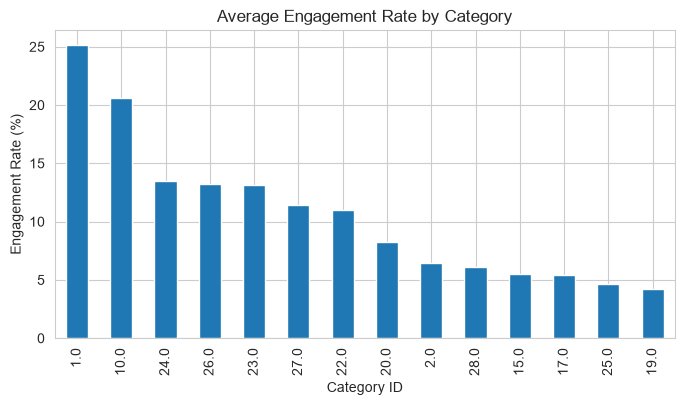

In [9]:
cat_avg = df.groupby("category_id")["engagement_rate"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
cat_avg.plot(kind="bar")
plt.title("Average Engagement Rate by Category")
plt.ylabel("Engagement Rate (%)")
plt.xlabel("Category ID")
plt.show()

## 6. Correlation heatmap — IMPORTANT (leakage check)
This should visually confirm: like_rate, comment_rate, views, likes, comments
are highly correlated with engagement_rate (since engagement_rate is derived
from them). These CANNOT be used as input features for prediction.

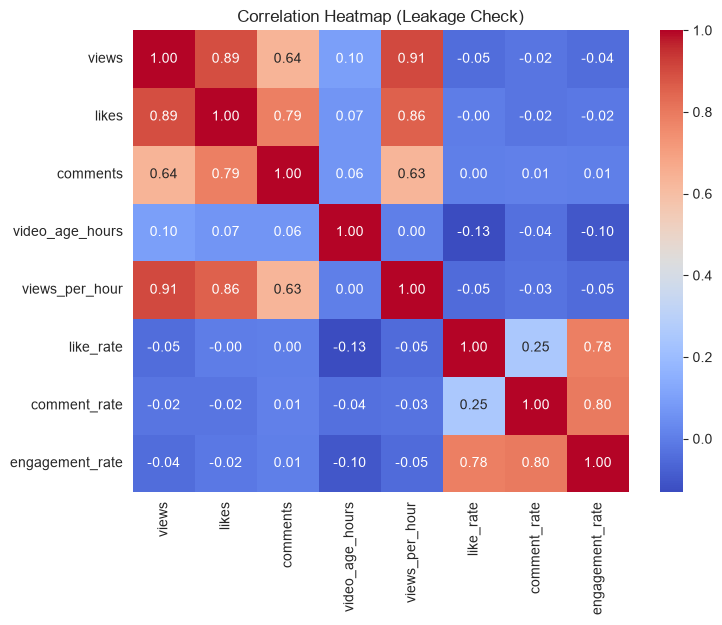

In [10]:
numeric_cols = ["views", "likes", "comments", "video_age_hours",
                 "views_per_hour", "like_rate", "comment_rate", "engagement_rate"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Leakage Check)")
plt.show()

## 7. Sample growth curve — pick a few videos and plot engagement over time
This is the visual that explains WHY we're doing early-window -> future-value
prediction instead of just using a single snapshot per video.

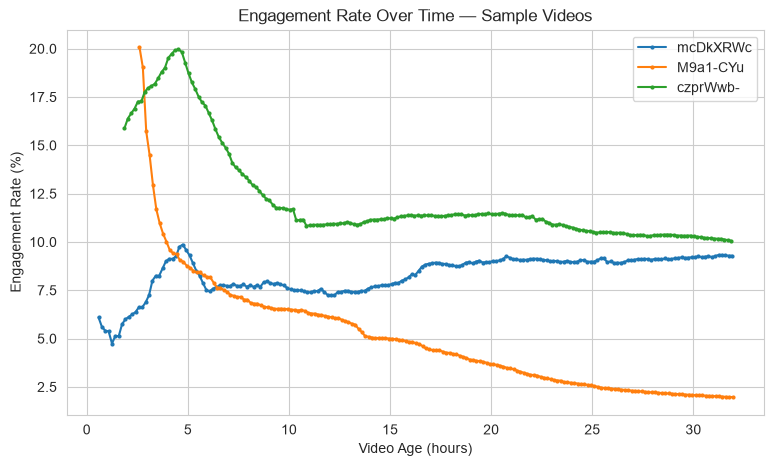

In [11]:
sample_ids = snapshots_per_video[snapshots_per_video > 50].sample(3, random_state=42).index

plt.figure(figsize=(9, 5))
for vid in sample_ids:
    vid_df = df[df["video_id"] == vid].sort_values("video_age_hours")
    plt.plot(vid_df["video_age_hours"], vid_df["engagement_rate"], marker="o", markersize=2, label=vid[:8])

plt.title("Engagement Rate Over Time — Sample Videos")
plt.xlabel("Video Age (hours)")
plt.ylabel("Engagement Rate (%)")
plt.legend()
plt.show()

## 8. Check target-window feasibility
Confirm how many videos have BOTH an early snapshot (<=6h) and a
"future" snapshot in the 18-30h window. This defines our final usable sample.

In [12]:
EARLY_CUTOFF = 6      # hours
TARGET_LOW, TARGET_HIGH = 18, 30   # hours

has_early = set(df[df["video_age_hours"] <= EARLY_CUTOFF]["video_id"].unique())
has_target = set(df[(df["video_age_hours"] >= TARGET_LOW) &
                     (df["video_age_hours"] <= TARGET_HIGH)]["video_id"].unique())
usable_videos = has_early & has_target

print(f"Videos with early snapshot (<= {EARLY_CUTOFF}h): {len(has_early)}")
print(f"Videos with target snapshot ({TARGET_LOW}-{TARGET_HIGH}h): {len(has_target)}")
print(f"Usable videos (both): {len(usable_videos)}")

Videos with early snapshot (<= 6h): 621
Videos with target snapshot (18-30h): 569
Usable videos (both): 537


## 9. Cleaning
Strategy:
- Sort by video_id + snapshot time
- Static fields (title, channel, category_id, duration, published_at):
  fill forward/backward within each video group (they shouldn't change)
- Counters (views, likes, comments): forward-fill within each video
  (monotonically non-decreasing, so last known value is a fair estimate)
- Derived ratios (like_rate, comment_rate, engagement_rate): RECOMPUTE
  after filling raw counts, rather than filling the ratios directly

In [13]:
df["published_at"] = pd.to_datetime(df["published_at"], utc=True)
df["snapshot_time"] = pd.to_datetime(df["snapshot_time"], utc=True)

df = df.sort_values(["video_id", "snapshot_time"]).reset_index(drop=True)

static_cols = ["title", "channel", "category_id", "duration", "published_at"]
for col in static_cols:
    df[col] = df.groupby("video_id")[col].transform(lambda x: x.ffill().bfill())

count_cols = ["views", "likes", "comments"]
for col in count_cols:
    df[col] = df.groupby("video_id")[col].transform(lambda x: x.ffill().bfill())

# ROOT-CAUSE FIX: views, likes, and comments are cumulative counters that
# should NEVER legitimately decrease over time. YouTube periodically
# recalibrates view counts downward (anti-bot/spam filtering), which shows
# up as a temporary dip in an otherwise-increasing sequence. Capping the
# resulting rate (tried first) only treats the symptom — a snapshot with a
# genuinely-dipped view count still produces a distorted rate for THAT
# snapshot. The proper fix corrects the counter itself: enforce monotonic
# non-decreasing values per video using a running maximum. This eliminates
# the artifact at its source rather than papering over the result.
df = df.sort_values(["video_id", "snapshot_time"])
for col in count_cols:
    df[col] = df.groupby("video_id")[col].cummax()

# Recompute derived ratios from the corrected (monotonic) counters.
safe_views = df["views"].clip(lower=1)
df["like_rate"] = (df["likes"] / safe_views) * 100
df["comment_rate"] = (df["comments"] / safe_views) * 100
df["engagement_rate"] = ((df["likes"] + df["comments"]) / safe_views) * 100

# NOTE: We do NOT cap these rate values. Capping a value that becomes a
# regression TARGET is bad practice — it creates an artificial ceiling
# that teaches the model a false "wall", and forces unrelated videos into
# false ties at the same clipped number. A small number of genuinely high
# ratios remain even after the cummax fix, most likely due to YouTube's
# view-counting delay (a view requires a minimum watch time to count,
# while a like/comment registers instantly — so a small-audience video can
# briefly show more likes+comments than counted views). Rather than
# distorting these values, we flag them here and let Day 2 EXCLUDE the
# affected videos entirely as a documented data-quality decision, instead
# of silently corrupting their target value.
implausible_threshold = 50.0  # informational only, not applied here
n_implausible = (df["engagement_rate"] > implausible_threshold).sum()
print(f"\nRows with engagement_rate > {implausible_threshold}% (informational, not removed here): {n_implausible}")

# Drop any rows that still have NaN in critical numeric columns after all
# fixes (a tiny residual from source data gaps that couldn't be recovered)
before_drop = df.shape[0]
df = df.dropna(subset=["views", "likes", "comments", "like_rate", "comment_rate", "engagement_rate"])
print(f"Dropped {before_drop - df.shape[0]} rows with unrecoverable nulls after cleaning")

print("\nSanity check — any infinite values remaining?")
print(np.isinf(df[["like_rate", "comment_rate", "engagement_rate"]]).sum())


Rows with engagement_rate > 50.0% (informational, not removed here): 2807
Dropped 0 rows with unrecoverable nulls after cleaning

Sanity check — any infinite values remaining?
like_rate          0
comment_rate       0
engagement_rate    0
dtype: int64


## 10. Parse duration (ISO 8601, e.g. PT6M12S) into seconds
Needed as a numeric feature for Day 2.

In [14]:
import re

def parse_duration_to_seconds(duration_str):
    if pd.isna(duration_str):
        return np.nan
    match = re.match(r"PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?", str(duration_str))
    if not match:
        return np.nan
    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0
    return hours * 3600 + minutes * 60 + seconds

df["duration_seconds"] = df["duration"].apply(parse_duration_to_seconds)
df[["duration", "duration_seconds"]].drop_duplicates().head()

,duration,duration_seconds
0,PT9M17S,557.0
144,PT9M59S,599.0
330,PT2M59S,179.0
509,PT1M8S,68.0
698,PT2M,120.0


## 11. Keep only videos usable for our modeling design
(has both an early snapshot and a target-window snapshot)

In [15]:
df_clean = df[df["video_id"].isin(usable_videos)].copy()
print("Rows before filtering to usable videos:", df.shape[0])
print("Rows after filtering:", df_clean.shape[0])
print("Unique usable videos:", df_clean["video_id"].nunique())

Rows before filtering to usable videos: 105718
Rows after filtering: 96825
Unique usable videos: 537


## 12. Save cleaned data for Day 2

In [16]:
df_clean.to_csv(PROCESSED_PATH, index=False)
print(f"Saved cleaned data to {PROCESSED_PATH}")
print(df_clean.shape)

Saved cleaned data to C:/Users/Lenovo/youtube_enagagement_project/data/processed/03cleaned_data_v2_upgrade.csv
(96825, 16)
